In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

age = np.random.randint(18, 80, n)
fever = np.random.randint(0, 2, n)
cough = np.random.randint(0, 2, n)
fatigue = np.random.randint(0, 2, n)
headache = np.random.randint(0, 2, n)
body_pain = np.random.randint(0, 2, n)
breathing_difficulty = np.random.randint(0, 2, n)

blood_pressure = np.random.randint(90, 180, n)
cholesterol = np.random.randint(120, 300, n)

risk_score = (
    0.03 * age
    + 1.5 * fever
    + 1.2 * cough
    + 1.0 * fatigue
    + 0.8 * headache
    + 1.2 * body_pain
    + 2.0 * breathing_difficulty
    + 0.02 * blood_pressure
    + 0.01 * cholesterol
)

threshold = np.median(risk_score)

disease = (risk_score >= threshold).astype(int)

df = pd.DataFrame({
    "Age": age,
    "Fever": fever,
    "Cough": cough,
    "Fatigue": fatigue,
    "Headache": headache,
    "BodyPain": body_pain,
    "BreathingDifficulty": breathing_difficulty,
    "BloodPressure": blood_pressure,
    "Cholesterol": cholesterol,
    "Disease": disease
})


In [2]:
df["Disease"].value_counts()

,count
Disease,
0,500
1,500


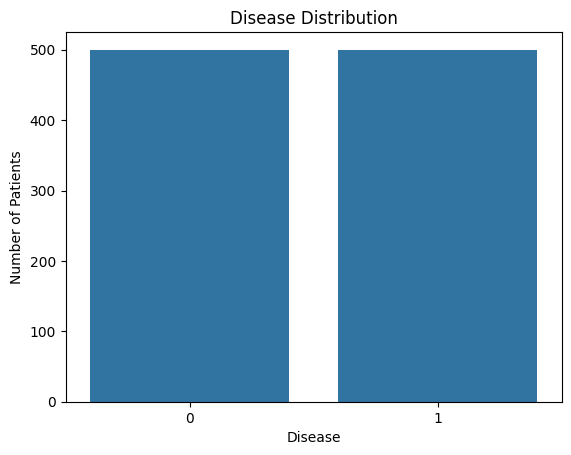

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Disease", data=df)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")

plt.show()

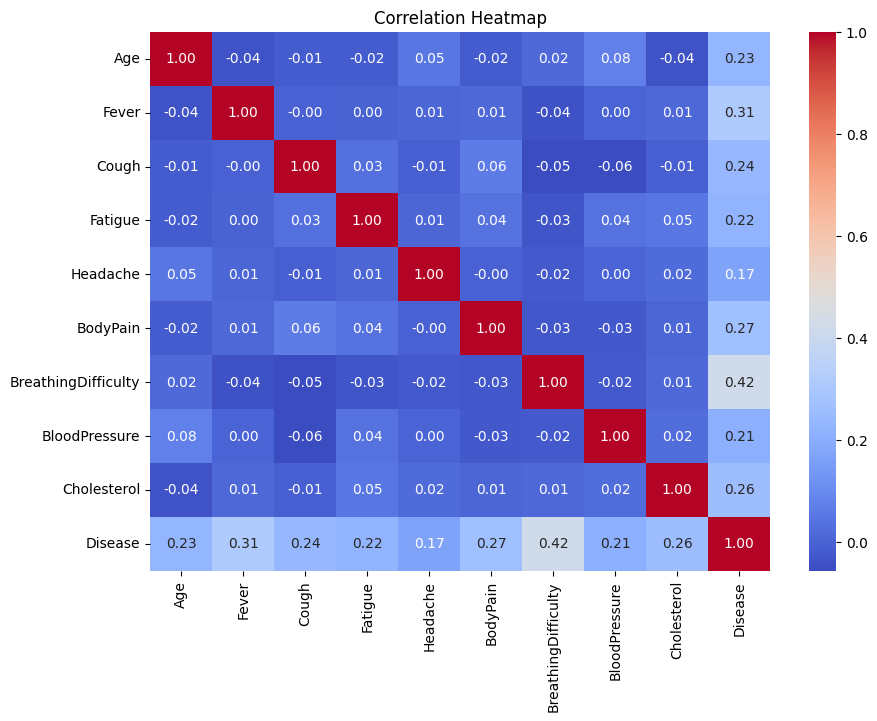

In [4]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

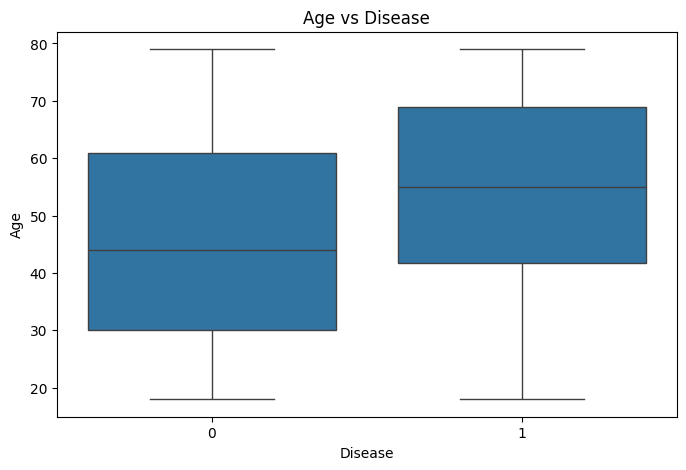

In [5]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Disease",
    y="Age",
    data=df
)

plt.title("Age vs Disease")

plt.show()

In [6]:
X = df.drop(
    "Disease",
    axis=1
)

y = df["Disease"]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Disease")



Features:
['Age', 'Fever', 'Cough', 'Fatigue', 'Headache', 'BodyPain', 'BreathingDifficulty', 'BloodPressure', 'Cholesterol']

Target:
Disease


In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import joblib

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 800
Testing Samples: 200


In [9]:
model = DecisionTreeClassifier(

    criterion="gini",

    max_depth=5,

    random_state=42

)

In [10]:
model.fit(
    X_train,
    y_train
)

y_pred = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)